In [1]:
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import numpy as np
sc.settings.n_jobs = 60

In [27]:
def process_adata(adata, 
                  subset_hvgs=False, 
                  run_harmony=False, 
                  harmony_key=["sample.sampleKitGuid"], 
                  resolution=1.0, 
                  run_rank_genes=False):
    
    if adata.raw is None:
        print("No adata.raw found. Please ensure raw data exists before processing.")
        return None

    # Extract raw and re-assign
    adata = adata.raw.to_adata()
    adata.raw = adata

    # mitochondrial genes
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    # ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    # hemoglobin genes
    adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
    )

    # Normalize and log1p
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    # HVG selection
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
    # Optional: Subset to HVGs
    if subset_hvgs:
        adata = adata[:, adata.var['highly_variable']].copy()

    # Scale and PCA
    sc.pp.scale(adata, max_value=10, zero_center=False)
    sc.tl.pca(adata, svd_solver="arpack")
    adata.obsm["X_pca_temp"] = adata.obsm["X_pca"]

    # Optional: Harmonize on a metadata parameter
    if run_harmony:
        sce.pp.harmony_integrate(adata, key=harmony_key)
        adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"]

    # Neighbors and dimensionality reduction
    sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_pca", n_pcs=20)
    sc.tl.tsne(adata, n_pcs=20)
    sc.tl.umap(adata, min_dist=0.45, random_state=0, n_components=2)
    sc.tl.leiden(adata, resolution=resolution, flavor="igraph", n_iterations=2)

    # Optional: Rank genes (leiden)
    if run_rank_genes:
        sc.tl.rank_genes_groups(
            adata, groupby="leiden", method="t-test", corr_method="benjamini-hochberg"
        )

    return adata

In [13]:
adata = sc.read_h5ad('../../../data/rna/pbmc-subsets/pbmc-mono_dc-processed-harmony.h5ad')

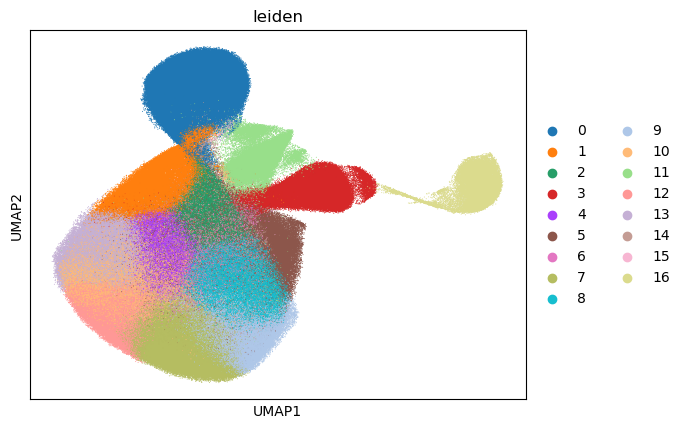

In [14]:
sc.pl.umap(adata, color='leiden', size=2)

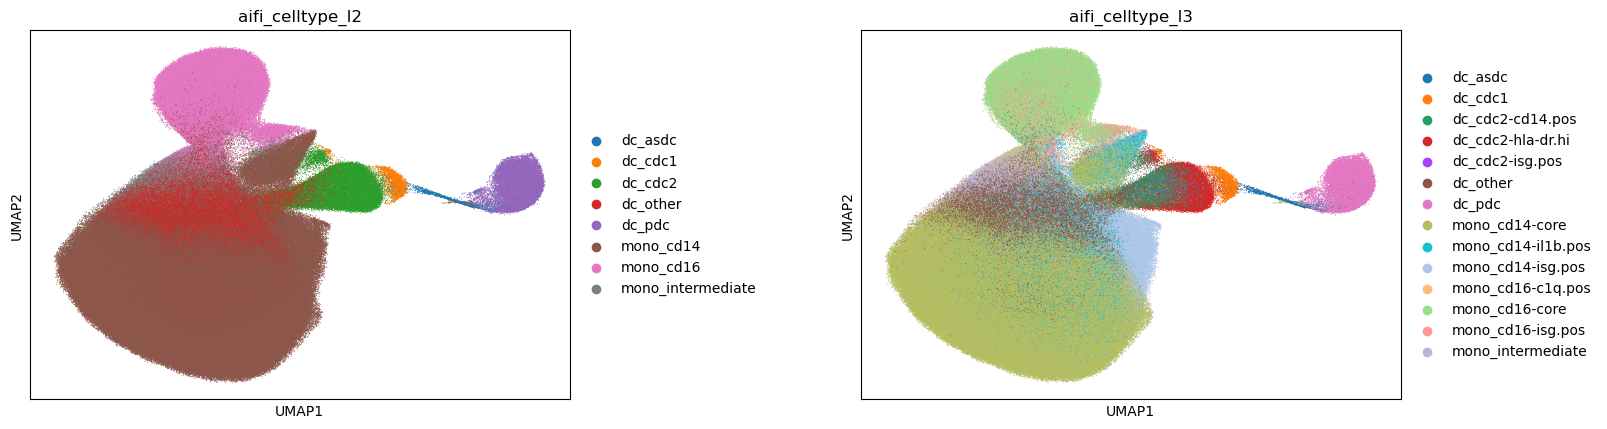

In [87]:
sc.pl.umap(adata, color=['aifi_celltype_l2', 'aifi_celltype_l3'], wspace=0.4, size=2)

In [34]:
dc_other = adata[adata.obs['aifi_celltype_l2'] == 'dc_other']

In [36]:
dc_other = process_adata(
    dc_other,
    subset_hvgs=False,
    run_harmony=True,
    harmony_key=["sample.sampleKitGuid"],
    resolution=0.8,
)

2025-10-20 21:46:33,402 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-20 21:46:37,895 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-20 21:46:38,300 - harmonypy - INFO - Iteration 1 of 10
2025-10-20 21:47:28,936 - harmonypy - INFO - Iteration 2 of 10
2025-10-20 21:48:20,308 - harmonypy - INFO - Iteration 3 of 10
2025-10-20 21:49:08,335 - harmonypy - INFO - Iteration 4 of 10
2025-10-20 21:49:57,316 - harmonypy - INFO - Iteration 5 of 10
2025-10-20 21:50:33,514 - harmonypy - INFO - Iteration 6 of 10
2025-10-20 21:51:04,117 - harmonypy - INFO - Iteration 7 of 10
2025-10-20 21:51:28,111 - harmonypy - INFO - Iteration 8 of 10
2025-10-20 21:51:49,022 - harmonypy - INFO - Iteration 9 of 10
2025-10-20 21:52:10,539 - harmonypy - INFO - Iteration 10 of 10
2025-10-20 21:52:36,412 - harmonypy - INFO - Stopped before convergence
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previ

In [98]:
dc_other.obs['tidy.aifi_l3'] = dc_other.obs['leiden'].apply(
    lambda x: 'Intermediate monocyte' if x in ['5', '6'] else 'Core CD14 monocyte'
)

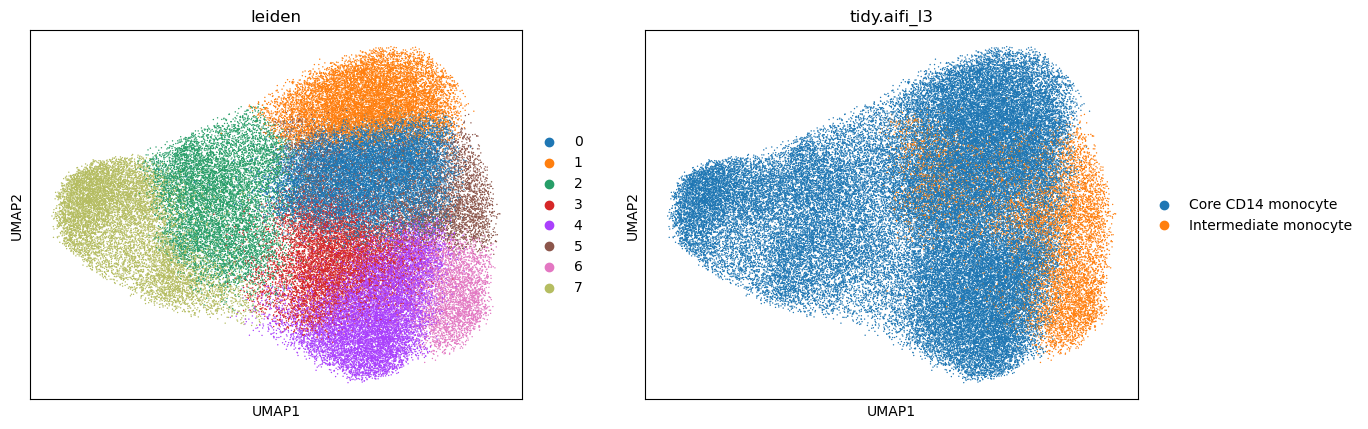

In [99]:
sc.pl.umap(dc_other, color=['leiden', 'tidy.aifi_l3'], size=4)

In [100]:
dc_other

AnnData object with n_obs × n_vars = 71622 × 31915
    obs: 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response', 'aifi_label_l1', 'aifi_celltype_l1', 'aifi_label_l2', 'aifi_celltype_l2', 'aifi_label_l3', 'aifi_celltype_l3', 's

In [101]:
dc_other.obs[['tidy.aifi_l3']].to_parquet('../../../data/rna/pbmc-labels/mono_dc_labels.parquet')